# Data Augmentation and Class Balancing

This notebook prepares an augmented version of the waste image dataset. The original clean dataset is not modified. Instead, a new dataset folder is created for the augmented data.

The main goal of this step is to reduce class imbalance in the training set. During the exploratory data analysis, we observed that the training set was not equally distributed across all waste categories. In particular, the trash class had significantly fewer images than the other classes.

To address this issue, only the training set is augmented. The validation and test sets are copied without modification, because they should represent unseen data and must remain realistic for model evaluation.

Several augmentation techniques are applied, such as horizontal flipping, rotation, shifting, scaling, brightness and contrast changes, and noise. These transformations help increase the number of training images and improve the model's ability to generalize.

After augmentation, each class in the training set contains the same number of images. This creates a more balanced training dataset for the classification models used in the next notebooks.

In [2]:
# ============================================================
# 1) Imports
# ============================================================

import os
from pathlib import Path
from PIL import Image

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
# ============================================================
# 2) Dataset Paths
# ============================================================

PROJECT_ROOT = Path.cwd()

# Dataset path relative to the project folder
base_dir = PROJECT_ROOT / "dataset" / "clean_split_dataset"
train_dir = base_dir / "train"
valid_dir = base_dir / "val"
test_dir  = base_dir / "test"

splits = {
    "train": train_dir,
    "val": valid_dir,
    "test": test_dir
}

image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

print("Base directory:", base_dir)
print("Train exists:", train_dir.exists())
print("Val exists:", valid_dir.exists())
print("Test exists:", test_dir.exists())

Base directory: c:\Users\gokce\Desktop\FHNWfs26\CLX\dataset\clean_split_dataset
Train exists: True
Val exists: True
Test exists: True


In [6]:
# ============================================================
# 3) Count Images per Split and Class
# ============================================================

count_records = []

for split_name, split_path in splits.items():
    for class_path in split_path.iterdir():
        if class_path.is_dir():
            image_files = [
                file for file in class_path.iterdir()
                if file.suffix.lower() in image_extensions
            ]

            count_records.append({
                "split": split_name,
                "class": class_path.name,
                "image_count": len(image_files)
            })

count_df = pd.DataFrame(count_records)

print("Image counts:")
print(count_df)

print("\nPivot table:")
count_pivot = count_df.pivot(index="class", columns="split", values="image_count")
print(count_pivot)

print("\nTotal images:")
print(count_df.groupby("split")["image_count"].sum())

Image counts:
    split      class  image_count
0   train  cardboard          282
1   train      glass          350
2   train      metal          286
3   train      paper          415
4   train    plastic          336
5   train      trash           95
6     val  cardboard           80
7     val      glass          100
8     val      metal           81
9     val      paper          118
10    val    plastic           96
11    val      trash           27
12   test  cardboard           41
13   test      glass           51
14   test      metal           42
15   test      paper           61
16   test    plastic           48
17   test      trash           15

Pivot table:
split      test  train  val
class                      
cardboard    41    282   80
glass        51    350  100
metal        42    286   81
paper        61    415  118
plastic      48    336   96
trash        15     95   27

Total images:
split
test      258
train    1764
val       502
Name: image_count, dtype: int64


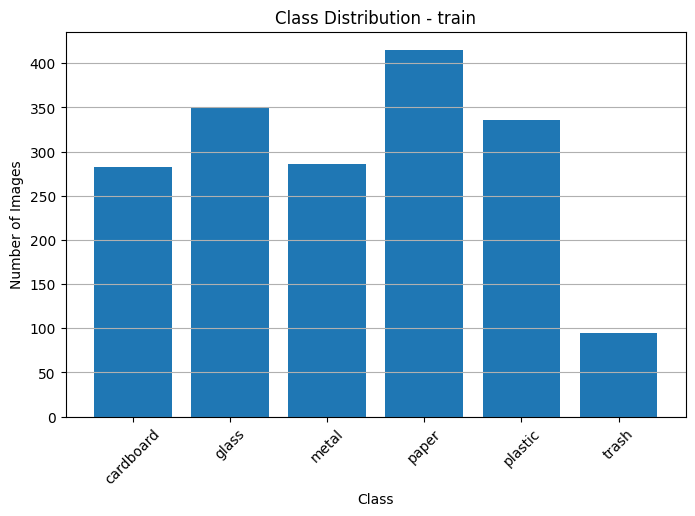

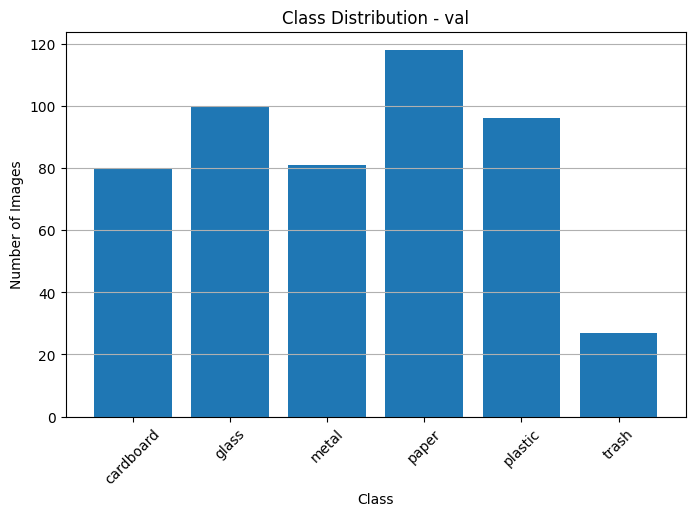

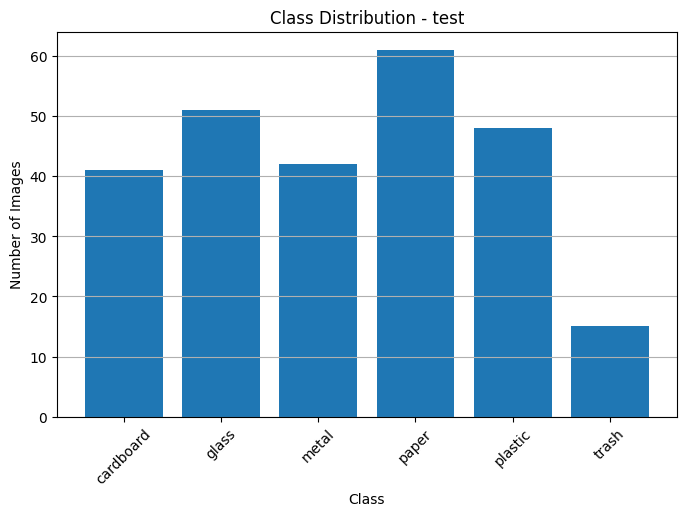

In [4]:
# ============================================================
# 4) Plot Class Distribution
# ============================================================

for split_name in ["train", "val", "test"]:
    split_data = count_df[count_df["split"] == split_name]

    plt.figure(figsize=(8, 5))
    plt.bar(split_data["class"], split_data["image_count"])
    plt.title(f"Class Distribution - {split_name}")
    plt.xlabel("Class")
    plt.ylabel("Number of Images")
    plt.xticks(rotation=45)
    plt.grid(axis="y")
    plt.show()

In [5]:
# ============================================================
# 5) Check Original Image Sizes
# ============================================================

image_size_records = []

for split_name, split_path in splits.items():
    for class_path in split_path.iterdir():
        if class_path.is_dir():
            class_name = class_path.name

            for image_path in class_path.iterdir():
                if image_path.suffix.lower() in image_extensions:
                    try:
                        with Image.open(image_path) as img:
                            width, height = img.size

                        image_size_records.append({
                            "split": split_name,
                            "class": class_name,
                            "filename": image_path.name,
                            "width": width,
                            "height": height,
                            "size": f"{width}x{height}"
                        })

                    except Exception as e:
                        print(f"Could not read image: {image_path}")
                        print(e)

image_sizes_df = pd.DataFrame(image_size_records)

print("Total images checked:", len(image_sizes_df))
print("\nFirst rows:")
print(image_sizes_df.head())

Total images checked: 2524

First rows:
   split      class          filename  width  height     size
0  train  cardboard    cardboard1.jpg    512     384  512x384
1  train  cardboard   cardboard10.jpg    512     384  512x384
2  train  cardboard  cardboard100.jpg    512     384  512x384
3  train  cardboard  cardboard102.jpg    512     384  512x384
4  train  cardboard  cardboard103.jpg    512     384  512x384


In [6]:
# ============================================================
# 6) Image Size Summary
# ============================================================

print("Number of unique image sizes:", image_sizes_df["size"].nunique())

print("\nMost common image sizes:")
print(image_sizes_df["size"].value_counts().head(20))

print("\nWidth summary:")
print(image_sizes_df["width"].describe())

print("\nHeight summary:")
print(image_sizes_df["height"].describe())

Number of unique image sizes: 1

Most common image sizes:
size
512x384    2524
Name: count, dtype: int64

Width summary:
count    2524.0
mean      512.0
std         0.0
min       512.0
25%       512.0
50%       512.0
75%       512.0
max       512.0
Name: width, dtype: float64

Height summary:
count    2524.0
mean      384.0
std         0.0
min       384.0
25%       384.0
50%       384.0
75%       384.0
max       384.0
Name: height, dtype: float64


In [7]:
# ============================================================
# 7) Image Size Summary by Split
# ============================================================

split_size_summary = image_sizes_df.groupby("split").agg(
    total_images=("filename", "count"),
    unique_sizes=("size", "nunique"),
    min_width=("width", "min"),
    max_width=("width", "max"),
    min_height=("height", "min"),
    max_height=("height", "max")
)

print(split_size_summary)

       total_images  unique_sizes  min_width  max_width  min_height  \
split                                                                 
test            258             1        512        512         384   
train          1764             1        512        512         384   
val             502             1        512        512         384   

       max_height  
split              
test          384  
train         384  
val           384  


In [8]:
# ============================================================
# 8) Image Size Summary by Class
# ============================================================

class_size_summary = image_sizes_df.groupby("class").agg(
    total_images=("filename", "count"),
    unique_sizes=("size", "nunique"),
    min_width=("width", "min"),
    max_width=("width", "max"),
    min_height=("height", "min"),
    max_height=("height", "max")
)

print(class_size_summary)

           total_images  unique_sizes  min_width  max_width  min_height  \
class                                                                     
cardboard           403             1        512        512         384   
glass               501             1        512        512         384   
metal               409             1        512        512         384   
paper               594             1        512        512         384   
plastic             480             1        512        512         384   
trash               137             1        512        512         384   

           max_height  
class                  
cardboard         384  
glass             384  
metal             384  
paper             384  
plastic           384  
trash             384  


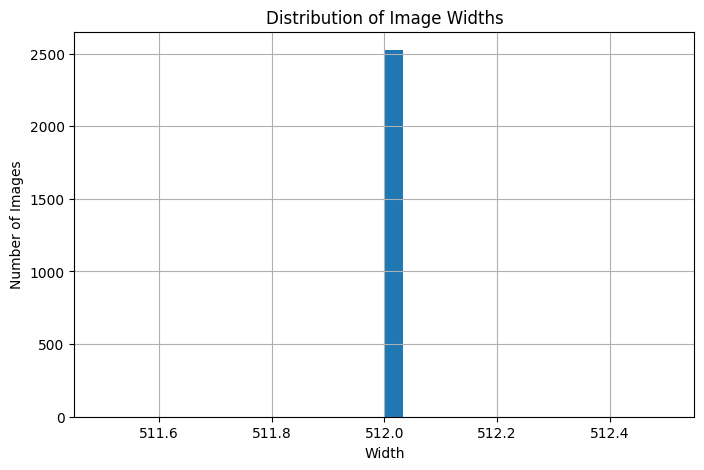

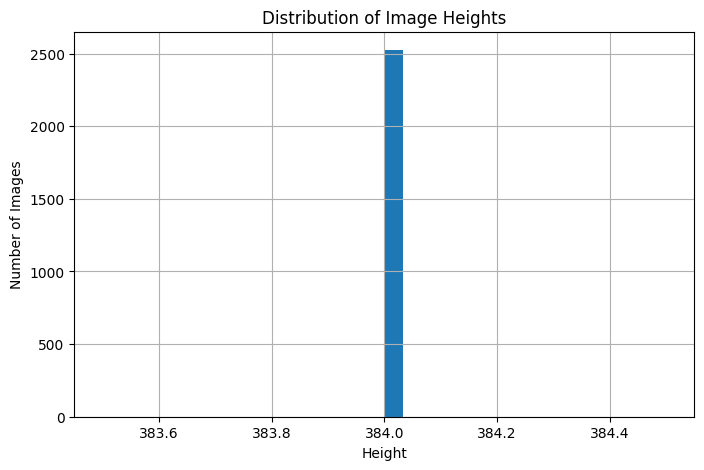

In [9]:
# ============================================================
# 9) Plot Width and Height Distributions
# ============================================================

plt.figure(figsize=(8, 5))
plt.hist(image_sizes_df["width"], bins=30)
plt.xlabel("Width")
plt.ylabel("Number of Images")
plt.title("Distribution of Image Widths")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(image_sizes_df["height"], bins=30)
plt.xlabel("Height")
plt.ylabel("Number of Images")
plt.title("Distribution of Image Heights")
plt.grid(True)
plt.show()

In [10]:
# ============================================================
# 11) Check Corrupted or Unreadable Images
# ============================================================

corrupted_images = []

for split_name, split_path in splits.items():
    for class_path in split_path.iterdir():
        if class_path.is_dir():
            for image_path in class_path.iterdir():
                if image_path.suffix.lower() in image_extensions:
                    try:
                        with Image.open(image_path) as img:
                            img.verify()
                    except Exception:
                        corrupted_images.append({
                            "split": split_name,
                            "class": class_path.name,
                            "path": str(image_path)
                        })

corrupted_df = pd.DataFrame(corrupted_images)

print("Number of corrupted/unreadable images:", len(corrupted_df))

if len(corrupted_df) > 0:
    print(corrupted_df.head())
else:
    print("No corrupted images found.")

Number of corrupted/unreadable images: 0
No corrupted images found.


In [11]:
# ============================================================
# 12) Check Data Leakage Between Splits
# ============================================================

def get_relative_image_paths(split_path):
    relative_paths = set()

    for class_path in split_path.iterdir():
        if class_path.is_dir():
            for image_path in class_path.iterdir():
                if image_path.suffix.lower() in image_extensions:
                    relative_paths.add(f"{class_path.name}/{image_path.name}")

    return relative_paths


train_files = get_relative_image_paths(train_dir)
val_files = get_relative_image_paths(valid_dir)
test_files = get_relative_image_paths(test_dir)

train_val_overlap = train_files & val_files
train_test_overlap = train_files & test_files
val_test_overlap = val_files & test_files

print("Train ∩ Val :", len(train_val_overlap))
print("Train ∩ Test:", len(train_test_overlap))
print("Val ∩ Test  :", len(val_test_overlap))

if train_val_overlap or train_test_overlap or val_test_overlap:
    print("\nData leakage detected.")
    print("Example Train-Test overlap:", list(train_test_overlap)[:10])
else:
    print("\nDataset is clean. No filename overlap between splits.")

Train ∩ Val : 0
Train ∩ Test: 0
Val ∩ Test  : 0

Dataset is clean. No filename overlap between splits.


Prepare Augmentation 

In [12]:
# ============================================================
# 13) Prepare Augmentation Output Folder
# ============================================================

import shutil
import random
import cv2
import albumentations as A

# New dataset folder. Original clean_split_dataset will NOT be changed.
output_dir = base_dir.parent / "clean_split_dataset_augmented"

output_train_dir = output_dir / "train"
output_valid_dir = output_dir / "val"
output_test_dir  = output_dir / "test"

# Get class names from the train folder
classes = sorted([
    class_path.name
    for class_path in train_dir.iterdir()
    if class_path.is_dir()
])

print("Classes:", classes)
print("Original dataset:", base_dir)
print("Augmented dataset will be saved to:", output_dir)

Classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Original dataset: C:\Users\gokce\Desktop\FHNWfs26\CLX\dataset\clean_split_dataset
Augmented dataset will be saved to: C:\Users\gokce\Desktop\FHNWfs26\CLX\dataset\clean_split_dataset_augmented


In [13]:
# ============================================================
# 14) Create Fresh Output Dataset Folder
# ============================================================

if output_dir.exists():
    shutil.rmtree(output_dir)

for split_name in ["train", "val", "test"]:
    for class_name in classes:
        class_output_dir = output_dir / split_name / class_name
        class_output_dir.mkdir(parents=True, exist_ok=True)

print("Fresh output dataset folder created.")

Fresh output dataset folder created.


In [14]:
# ============================================================
# 15) Copy Validation and Test Sets Without Augmentation
# ============================================================

def copy_split(source_split_dir, target_split_dir):
    """
    Copy all images from one split to another without modification.
    """
    for class_name in classes:
        source_class_dir = source_split_dir / class_name
        target_class_dir = target_split_dir / class_name

        for image_path in source_class_dir.iterdir():
            if image_path.suffix.lower() in image_extensions:
                shutil.copy2(image_path, target_class_dir / image_path.name)


copy_split(valid_dir, output_valid_dir)
copy_split(test_dir, output_test_dir)

print("Validation and test sets copied without augmentation.")

Validation and test sets copied without augmentation.


In [15]:
# ============================================================
# 16) Copy Original Training Images
# ============================================================

copy_split(train_dir, output_train_dir)

print("Original training images copied.")

Original training images copied.


In [ ]:
# ============================================================
# 17) Define Augmentation Transforms
# ============================================================

transforms = [
    A.Compose([
        A.HorizontalFlip(p=1.0)   
    ]),

    A.Compose([
        A.ShiftScaleRotate(
            shift_limit=0.06,
            scale_limit=0.10,
            rotate_limit=45,
            p=1.0
        )
    ]),

    A.Compose([
        A.RandomBrightnessContrast(
            brightness_limit=0.25,
            contrast_limit=0.25,
            p=1.0
        )
    ]),

    A.Compose([
        A.GaussNoise(p=1.0)
    ])
]

print("Augmentation transforms are ready.")

Augmentation transforms are ready.


c:\Users\gokce\Desktop\FHNWfs26\CLX\venv311\Lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [17]:
# ============================================================
# 18) Decide Target Count for Training Classes
# ============================================================

train_count_df = count_df[count_df["split"] == "train"]

target_count = train_count_df["image_count"].max()

print("Original train counts:")
print(train_count_df)

print("\nTarget count per class:", target_count)

Original train counts:
   split      class  image_count
0  train  cardboard          282
1  train      glass          350
2  train      metal          286
3  train      paper          415
4  train    plastic          336
5  train      trash           95

Target count per class: 415


In [18]:
# ============================================================
# 19) Apply Augmentation to Balance Training Set
# ============================================================

def get_image_files(class_dir):
    """
    Return image files from a class directory.
    """
    return [
        file for file in class_dir.iterdir()
        if file.suffix.lower() in image_extensions
    ]


for class_name in classes:
    source_class_dir = train_dir / class_name
    target_class_dir = output_train_dir / class_name

    original_images = get_image_files(source_class_dir)
    current_images = get_image_files(target_class_dir)

    current_count = len(current_images)

    print(f"\nClass: {class_name}")
    print(f"Current train images: {current_count}")
    print(f"Target train images: {target_count}")

    augmented_index = 0

    while current_count < target_count:
        source_image_path = random.choice(original_images)

        # Read image with OpenCV
        image = cv2.imread(str(source_image_path))

        if image is None:
            print(f"Could not read image: {source_image_path}")
            continue

        # Apply one random augmentation transform
        transform = random.choice(transforms)
        augmented_image = transform(image=image)["image"]

        # Save augmented image in the new output folder
        augmented_filename = f"aug_{source_image_path.stem}_{augmented_index}.jpg"
        augmented_path = target_class_dir / augmented_filename

        cv2.imwrite(str(augmented_path), augmented_image)

        current_count += 1
        augmented_index += 1

    print(f"Final train images for {class_name}: {current_count}")

print("\nTraining set augmentation completed.")


Class: cardboard
Current train images: 282
Target train images: 415
Final train images for cardboard: 415

Class: glass
Current train images: 350
Target train images: 415
Final train images for glass: 415

Class: metal
Current train images: 286
Target train images: 415
Final train images for metal: 415

Class: paper
Current train images: 415
Target train images: 415
Final train images for paper: 415

Class: plastic
Current train images: 336
Target train images: 415
Final train images for plastic: 415

Class: trash
Current train images: 95
Target train images: 415
Final train images for trash: 415

Training set augmentation completed.


In [19]:
# ============================================================
# 20) Check Augmented Dataset Statistics
# ============================================================

augmented_splits = {
    "train": output_train_dir,
    "val": output_valid_dir,
    "test": output_test_dir
}

augmented_count_records = []

for split_name, split_path in augmented_splits.items():
    for class_name in classes:
        class_path = split_path / class_name

        image_files = [
            file for file in class_path.iterdir()
            if file.suffix.lower() in image_extensions
        ]

        augmented_count_records.append({
            "split": split_name,
            "class": class_name,
            "image_count": len(image_files)
        })

augmented_count_df = pd.DataFrame(augmented_count_records)

print("Augmented dataset counts:")
print(augmented_count_df)

print("\nPivot table:")
augmented_count_pivot = augmented_count_df.pivot(
    index="class",
    columns="split",
    values="image_count"
)

print(augmented_count_pivot)

print("\nTotal images:")
print(augmented_count_df.groupby("split")["image_count"].sum())

Augmented dataset counts:
    split      class  image_count
0   train  cardboard          415
1   train      glass          415
2   train      metal          415
3   train      paper          415
4   train    plastic          415
5   train      trash          415
6     val  cardboard           80
7     val      glass          100
8     val      metal           81
9     val      paper          118
10    val    plastic           96
11    val      trash           27
12   test  cardboard           41
13   test      glass           51
14   test      metal           42
15   test      paper           61
16   test    plastic           48
17   test      trash           15

Pivot table:
split      test  train  val
class                      
cardboard    41    415   80
glass        51    415  100
metal        42    415   81
paper        61    415  118
plastic      48    415   96
trash        15    415   27

Total images:
split
test      258
train    2490
val       502
Name: image_count, dtype: i

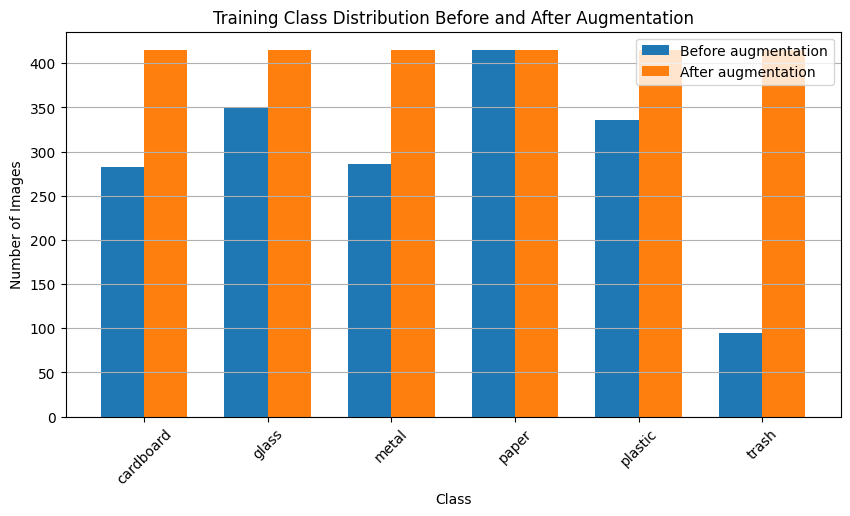

In [20]:
# ============================================================
# 21) Plot Train Distribution Before and After Augmentation
# ============================================================

before_train_df = count_df[count_df["split"] == "train"].copy()
before_train_df["dataset"] = "Before augmentation"

after_train_df = augmented_count_df[augmented_count_df["split"] == "train"].copy()
after_train_df["dataset"] = "After augmentation"

plt.figure(figsize=(10, 5))

x = np.arange(len(classes))
width = 0.35

before_counts = [
    before_train_df[before_train_df["class"] == class_name]["image_count"].values[0]
    for class_name in classes
]

after_counts = [
    after_train_df[after_train_df["class"] == class_name]["image_count"].values[0]
    for class_name in classes
]

plt.bar(x - width / 2, before_counts, width, label="Before augmentation")
plt.bar(x + width / 2, after_counts, width, label="After augmentation")

plt.xticks(x, classes, rotation=45)
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("Training Class Distribution Before and After Augmentation")
plt.legend()
plt.grid(axis="y")
plt.show()

In [21]:
# ============================================================
# 22) New Dataset Paths for Training
# ============================================================

train_dir = str(output_train_dir)
valid_dir = str(output_valid_dir)
test_dir  = str(output_test_dir)

print("Use these paths for training:")
print("train_dir:", train_dir)
print("valid_dir:", valid_dir)
print("test_dir :", test_dir)

Use these paths for training:
train_dir: C:\Users\gokce\Desktop\FHNWfs26\CLX\dataset\clean_split_dataset_augmented\train
valid_dir: C:\Users\gokce\Desktop\FHNWfs26\CLX\dataset\clean_split_dataset_augmented\val
test_dir : C:\Users\gokce\Desktop\FHNWfs26\CLX\dataset\clean_split_dataset_augmented\test
